**Run note:** execute this notebook's first setup/code cell before any later cells. Each notebook is designed to run independently and re-detect the dataset path on its own.

# 03 â€” Exploratory Data Analysis (EDA)

Deep linguistic and visual analysis: word frequencies, slurs, target groups, visual patterns, label bias, benign confederation test.

In [29]:
import os
import json
import re
from collections import Counter
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
from wordcloud import WordCloud

ON_KAGGLE = Path("/kaggle/input").is_dir()
JSONL_CANDIDATES = {
    "train": ["train.jsonl"],
    "dev": ["dev.jsonl", "dev_seen.jsonl", "dev_unseen.jsonl"],
    "test": ["test.jsonl", "test_seen.jsonl", "test_unseen.jsonl"],
}
IMAGE_DIR_CANDIDATES = ("img", "images")


def _has_image_dir(path: Path) -> bool:
    return any((path / name).is_dir() for name in IMAGE_DIR_CANDIDATES)


def _has_any_jsonl(path: Path, names) -> bool:
    return any((path / name).is_file() for name in names)


def _looks_like_dataset_root(path: Path) -> bool:
    return path.is_dir() and _has_image_dir(path) and _has_any_jsonl(path, JSONL_CANDIDATES["train"])


def detect_data_dir():
    for env_name in ("KAGGLE_DATA_DIR", "META_HATEFUL_MEME_DATA_DIR"):
        env_dir = os.environ.get(env_name, "").strip()
        if env_dir and _looks_like_dataset_root(Path(env_dir)):
            return Path(env_dir), f"env:{env_name}"

    kaggle_input = Path("/kaggle/input")
    default_candidate = kaggle_input / "meta-hateful-meme-detection" / "data"
    if _looks_like_dataset_root(default_candidate):
        return default_candidate, "default:/kaggle/input/meta-hateful-meme-detection/data"

    if ON_KAGGLE:
        for train_jsonl in sorted(kaggle_input.rglob("train.jsonl")):
            candidate = train_jsonl.parent
            if _looks_like_dataset_root(candidate):
                return candidate, f"auto:{candidate}"

        for candidate in sorted(kaggle_input.rglob("*")):
            if candidate.is_dir() and _looks_like_dataset_root(candidate):
                return candidate, f"auto:{candidate}"

    for candidate in (Path.cwd() / "data", Path.cwd().parent / "data", Path.cwd(), Path.cwd().parent):
        if _looks_like_dataset_root(candidate):
            return candidate, f"local:{candidate}"

    return None, "not-found"


def resolve_split(base_dir, names):
    base_dir = Path(base_dir)
    for name in names:
        path = base_dir / name
        if path.is_file():
            return path
    for name in names:
        matches = sorted(base_dir.rglob(name))
        if matches:
            return matches[0]
    return None


DATA_DIR, data_source = detect_data_dir()
if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset not found. Set KAGGLE_DATA_DIR or META_HATEFUL_MEME_DATA_DIR to the folder containing train.jsonl and img/."
    )

IMG_DIR = next((DATA_DIR / name for name in IMAGE_DIR_CANDIDATES if (DATA_DIR / name).is_dir()), None)
TRAIN_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES["train"])
DEV_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES["dev"])
OUTPUT_DIR = Path("/kaggle/working") if ON_KAGGLE else Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if TRAIN_PATH is None or DEV_PATH is None:
    raise FileNotFoundError(f"Expected train/dev splits under {DATA_DIR}")

DATA_DIR = str(DATA_DIR)
IMG_DIR = str(IMG_DIR) if IMG_DIR is not None else None
TRAIN_PATH = str(TRAIN_PATH)
DEV_PATH = str(DEV_PATH)
OUTPUT_DIR = str(OUTPUT_DIR)

print(f"Using DATA_DIR : {DATA_DIR}")
print(f"Using IMG_DIR  : {IMG_DIR}")
print(f"Using source   : {data_source}")
print(f"Output dir     : {OUTPUT_DIR}")


def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return pd.DataFrame([json.loads(l) for l in f])


train = load_jsonl(TRAIN_PATH)
dev = load_jsonl(DEV_PATH)

train["word_count"] = train["text"].str.split().str.len()
train["char_count"] = train["text"].str.len()
print(f"Train loaded: {len(train)} rows")

Using DATA_DIR : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Using IMG_DIR  : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data/img
Using source   : auto:/kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Output dir     : /kaggle/working
Train loaded: 8500 rows


In [30]:
from pathlib import Path


def resolve_image_path(data_dir, image_ref):
    data_dir = Path(data_dir)
    image_ref = Path(str(image_ref))

    candidates = []
    if image_ref.is_absolute():
        candidates.append(image_ref)

    candidates.extend([
        data_dir / image_ref,
        data_dir.parent / image_ref,
    ])

    if image_ref.parts:
        if image_ref.parts[0] in {"img", "images"} and len(image_ref.parts) > 1:
            stripped = Path(*image_ref.parts[1:])
            candidates.extend([
                data_dir / stripped,
                data_dir.parent / stripped,
            ])
        elif image_ref.parts[0] not in {"img", "images"}:
            candidates.extend([
                data_dir / "img" / image_ref,
                data_dir / "images" / image_ref,
                data_dir.parent / "img" / image_ref,
                data_dir.parent / "images" / image_ref,
            ])

    seen = set()
    for candidate in candidates:
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Could not find image '{image_ref}' relative to {data_dir}")

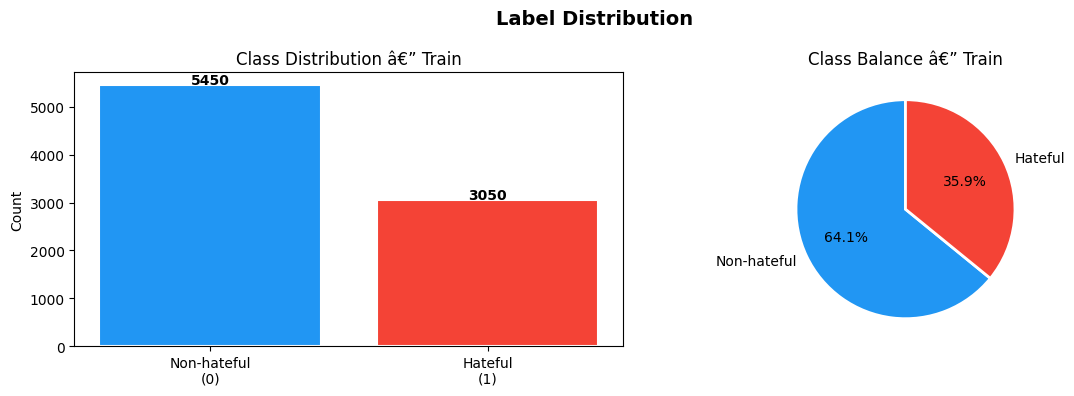

Non-hateful / Hateful ratio = 1.79 : 1


In [31]:
# â”€â”€ 3.1 Class distribution â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = train["label"].value_counts().sort_index()
axes[0].bar(["Non-hateful\n(0)", "Hateful\n(1)"], counts.values,
            color=["#2196F3", "#F44336"], edgecolor="white", linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")
axes[0].set_title("Class Distribution â€” Train")
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(counts.values, labels=["Non-hateful", "Hateful"],
            colors=["#2196F3", "#F44336"], autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class Balance â€” Train")

plt.suptitle("Label Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

imbalance_ratio = counts[0] / counts[1]
print(f"Non-hateful / Hateful ratio = {imbalance_ratio:.2f} : 1")

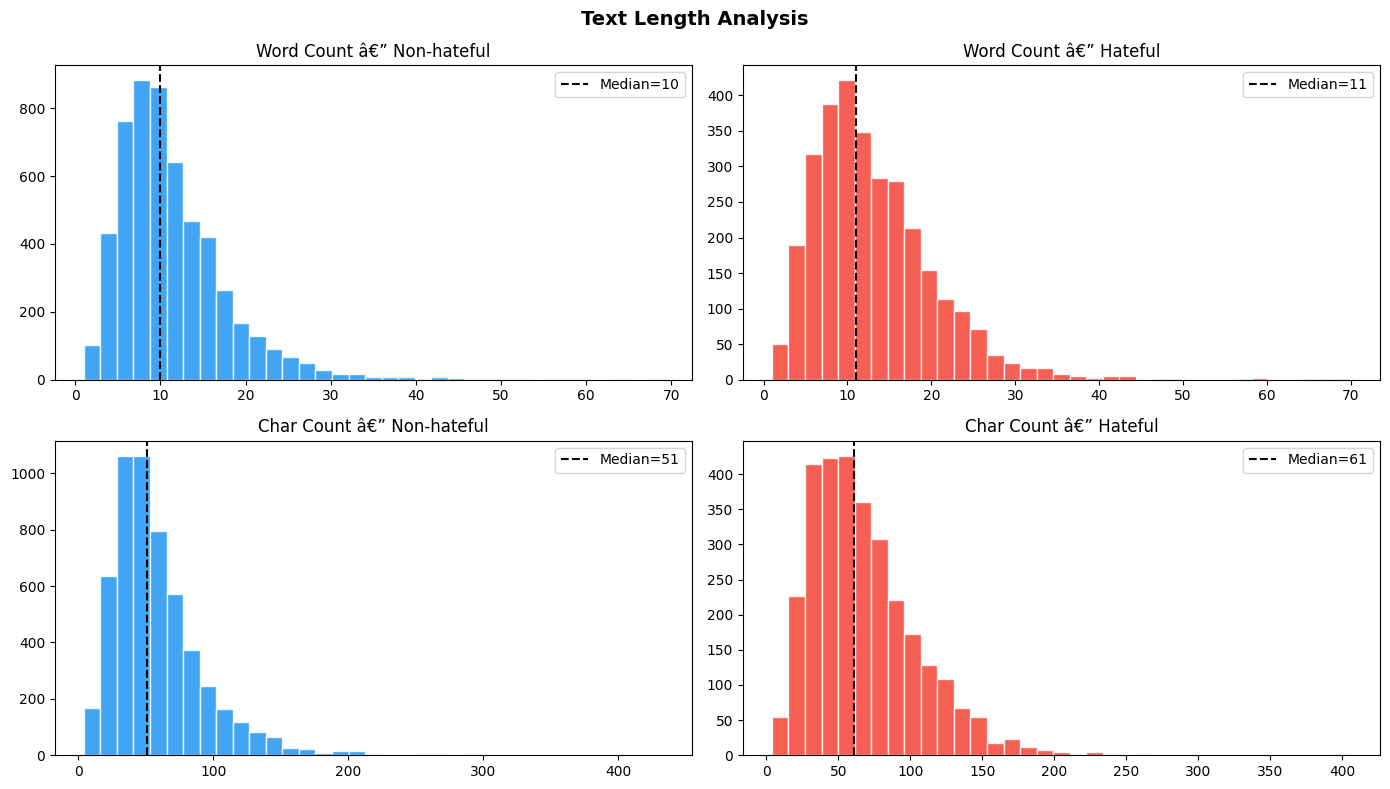

In [32]:
# â”€â”€ 3.2 Word count & character count distributions â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, row_idx, title in [("word_count", 0, "Word Count"), ("char_count", 1, "Char Count")]:
    for label, color, name, col_idx in [(0, "#2196F3", "Non-hateful", 0), (1, "#F44336", "Hateful", 1)]:
        data = train[train["label"] == label][col]
        ax = axes[row_idx][col_idx]
        ax.hist(data, bins=35, color=color, edgecolor="white", alpha=0.85)
        ax.axvline(data.median(), color="black", linestyle="--", label=f"Median={data.median():.0f}")
        ax.set_title(f"{title} â€” {name}")
        ax.legend()

plt.suptitle("Text Length Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [33]:
# ── 3.2a  Detailed Text Statistics ──────────────────────────────────────
train["avg_word_len"] = train["text"].apply(
    lambda t: np.mean([len(w) for w in t.split()]) if t.strip() else 0
)

stats_rows = []
for label, name in [(0, "Non-hateful"), (1, "Hateful"), (None, "Overall")]:
    subset = train if label is None else train[train["label"] == label]
    for col, col_name in [("word_count", "Word Count"), ("char_count", "Char Count"), ("avg_word_len", "Avg Word Length")]:
        s = subset[col]
        stats_rows.append({
            "Class": name,
            "Metric": col_name,
            "Mean": f"{s.mean():.2f}",
            "Median": f"{s.median():.1f}",
            "Std": f"{s.std():.2f}",
            "Min": f"{s.min():.0f}",
            "Max": f"{s.max():.0f}",
            "P25": f"{s.quantile(0.25):.1f}",
            "P75": f"{s.quantile(0.75):.1f}",
            "P90": f"{np.percentile(s, 90):.1f}",
            "P95": f"{np.percentile(s, 95):.1f}",
            "P99": f"{np.percentile(s, 99):.1f}",
        })

stats_df = pd.DataFrame(stats_rows)
print("═" * 80)
print("DETAILED TEXT STATISTICS (per class)")
print("═" * 80)
print(stats_df.to_string(index=False))
print()

# Quick highlight
overall_avg_wc = train["word_count"].mean()
overall_p95_wc = np.percentile(train["word_count"], 95)
overall_avg_wl = train["avg_word_len"].mean()
print(f"▸ Average word count (overall): {overall_avg_wc:.2f}")
print(f"▸ 95th percentile word count  : {overall_p95_wc:.0f}")
print(f"▸ Average word length (chars)  : {overall_avg_wl:.2f}")
print(f"▸ Hateful texts are {'longer' if train[train.label==1]['word_count'].mean() > train[train.label==0]['word_count'].mean() else 'shorter'} on average")

════════════════════════════════════════════════════════════════════════════════
DETAILED TEXT STATISTICS (per class)
════════════════════════════════════════════════════════════════════════════════
      Class          Metric  Mean Median   Std Min Max  P25  P75   P90   P95   P99
Non-hateful      Word Count 11.15   10.0  6.56   1  69  7.0 14.0  19.0  23.0  34.0
Non-hateful      Char Count 58.49   51.0 35.11   4 433 35.0 72.0 102.0 124.0 182.0
Non-hateful Avg Word Length  4.45    4.3  0.92   2  19  3.9  4.9   5.5   6.0   7.3
    Hateful      Word Count 12.79   11.0  7.30   1  70  8.0 17.0  22.0  26.0  35.0
    Hateful      Char Count 68.48   61.0 39.45   4 406 40.0 88.0 120.0 139.0 188.0
    Hateful Avg Word Length  4.56    4.4  0.95   2  19  4.0  5.0   5.6   6.2   7.7
    Overall      Word Count 11.74   10.0  6.88   1  70  7.0 15.0  21.0  24.0  34.0
    Overall      Char Count 62.08   54.0 37.04   4 433 37.0 78.0 110.0 131.0 186.0
    Overall Avg Word Length  4.49    4.3  0.93   2  19

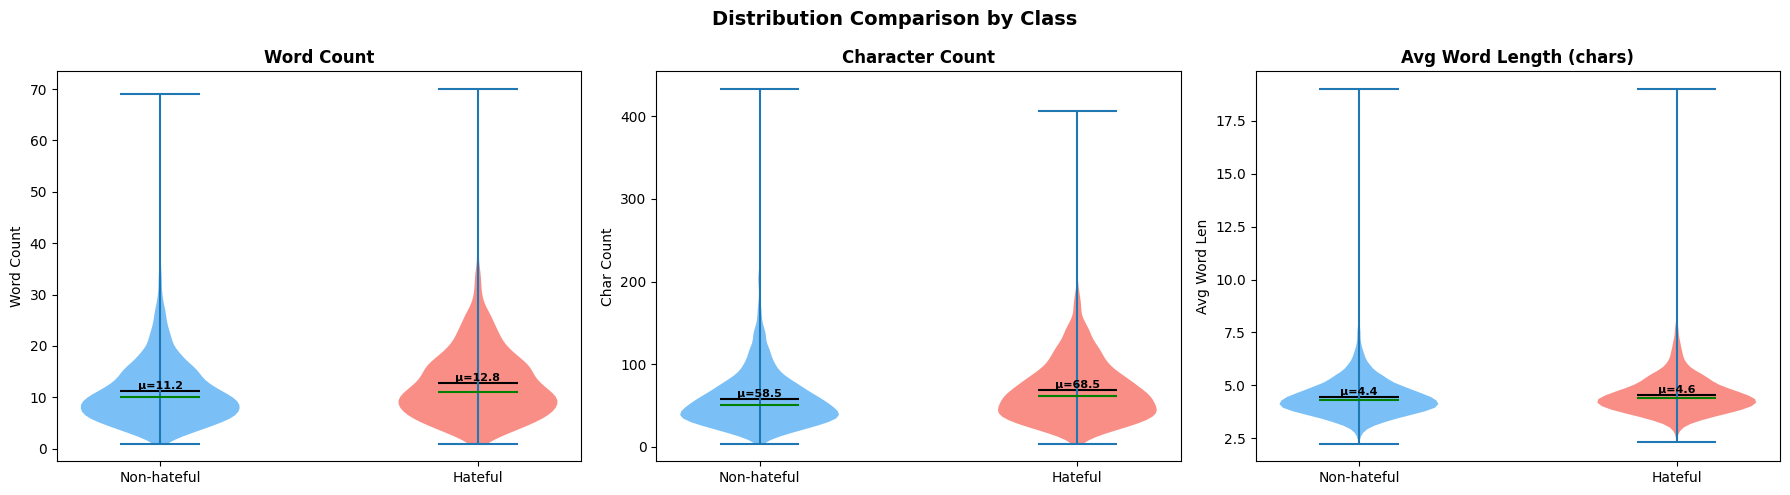

Word Count            U=7,109,160  p=1.33e-28  ***
Char Count            U=6,917,388  p=9.11e-38  ***
Avg Word Len          U=7,695,546  p=1.39e-08  ***


In [34]:
# ── 3.2b  Box Plots & Violin Plots ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

label_map = {0: "Non-hateful", 1: "Hateful"}
palette = {"Non-hateful": "#2196F3", "Hateful": "#F44336"}
train["label_name"] = train["label"].map(label_map)

for ax, col, title in zip(axes, ["word_count", "char_count", "avg_word_len"],
                           ["Word Count", "Character Count", "Avg Word Length (chars)"]):
    parts = ax.violinplot(
        [train[train.label == 0][col].values, train[train.label == 1][col].values],
        positions=[0, 1], showmeans=True, showmedians=True
    )
    for i, (pc, color) in enumerate(zip(parts["bodies"], ["#2196F3", "#F44336"])):
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
    parts["cmeans"].set_color("black")
    parts["cmedians"].set_color("green")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Non-hateful", "Hateful"])
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(col.replace("_", " ").title())

    # Annotate mean & median
    for i, lbl in enumerate([0, 1]):
        s = train[train.label == lbl][col]
        ax.text(i, s.mean(), f"μ={s.mean():.1f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.suptitle("Distribution Comparison by Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Statistical test (Mann-Whitney U)
from scipy.stats import mannwhitneyu
for col, name in [("word_count", "Word Count"), ("char_count", "Char Count"), ("avg_word_len", "Avg Word Len")]:
    stat, p = mannwhitneyu(train[train.label == 0][col], train[train.label == 1][col], alternative="two-sided")
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"{name:20s}  U={stat:,.0f}  p={p:.2e}  {sig}")

════════════════════════════════════════════════════════════════════════════════
VOCABULARY RICHNESS
════════════════════════════════════════════════════════════════════════════════
      Class Total Tokens Unique Words Type-Token Ratio Hapax Legomena Hapax % Top Word
Non-hateful       62,147        6,936           0.1116          3,439   49.6%      you
    Hateful       39,749        5,437           0.1368          2,824   51.9%      the
    Overall      101,896        8,638           0.0848          3,806   44.1%      you

Hapax legomena = words appearing only once (measure of vocabulary diversity)
Type-Token Ratio (TTR) = unique words / total words (lower = more repetitive)


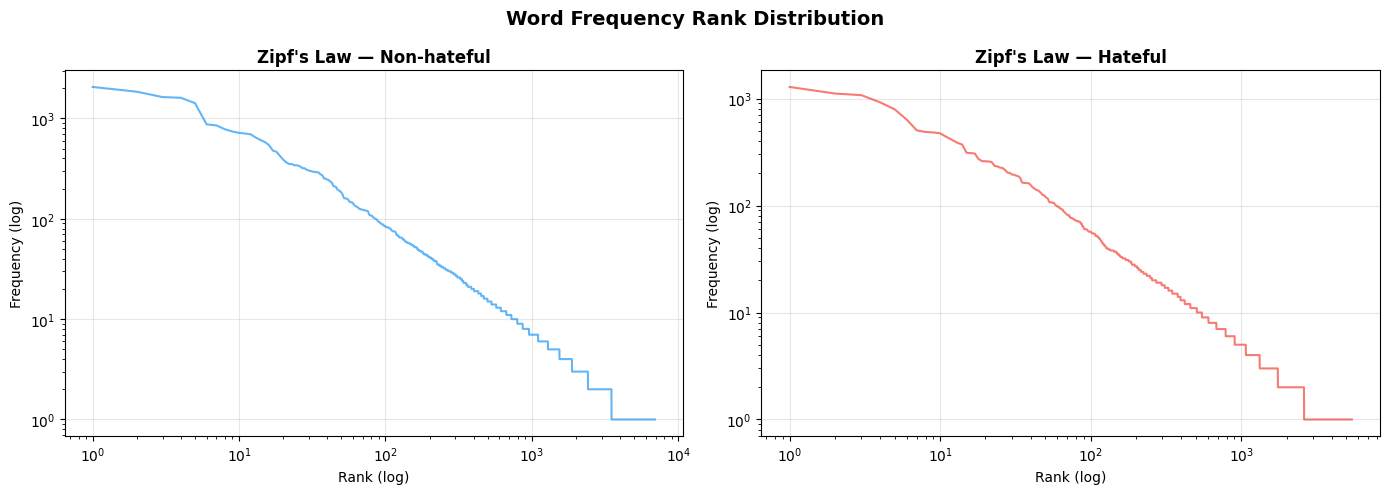

In [35]:
# ── 3.2c  Vocabulary & Lexical Richness ─────────────────────────────────
from collections import Counter

STOPWORDS = {"the", "a", "an", "is", "are", "was", "were", "be", "been",
             "to", "of", "and", "in", "it", "i", "you", "he", "she",
             "we", "they", "that", "this", "for", "on", "with", "do",
             "not", "but", "from", "at", "by", "as", "have", "has"}

vocab_rows = []
for label, name in [(0, "Non-hateful"), (1, "Hateful"), (None, "Overall")]:
    subset = train if label is None else train[train["label"] == label]
    all_tokens = [w for t in subset["text"].str.lower() for w in re.findall(r"\b[a-z]+\b", t)]
    freq = Counter(all_tokens)
    total = len(all_tokens)
    unique = len(freq)
    hapax = sum(1 for w, c in freq.items() if c == 1)  # words appearing exactly once
    vocab_rows.append({
        "Class": name,
        "Total Tokens": f"{total:,}",
        "Unique Words": f"{unique:,}",
        "Type-Token Ratio": f"{unique / total:.4f}" if total else "0",
        "Hapax Legomena": f"{hapax:,}",
        "Hapax %": f"{100 * hapax / unique:.1f}%" if unique else "0%",
        "Top Word": freq.most_common(1)[0][0] if freq else "-",
    })

vocab_df = pd.DataFrame(vocab_rows)
print("═" * 80)
print("VOCABULARY RICHNESS")
print("═" * 80)
print(vocab_df.to_string(index=False))
print()
print("Hapax legomena = words appearing only once (measure of vocabulary diversity)")
print("Type-Token Ratio (TTR) = unique words / total words (lower = more repetitive)")

# Zipf's law plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label, color, name in [(axes[0], 0, "#2196F3", "Non-hateful"), (axes[1], 1, "#F44336", "Hateful")]:
    tokens = [w for t in train[train.label == label]["text"].str.lower() for w in re.findall(r"\b[a-z]+\b", t)]
    freq = Counter(tokens)
    ranks = range(1, len(freq) + 1)
    sorted_freqs = sorted(freq.values(), reverse=True)
    ax.loglog(ranks, sorted_freqs, color=color, alpha=0.7, linewidth=1.5)
    ax.set_xlabel("Rank (log)")
    ax.set_ylabel("Frequency (log)")
    ax.set_title(f"Zipf's Law — {name}", fontweight="bold")
    ax.grid(True, alpha=0.3)

plt.suptitle("Word Frequency Rank Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

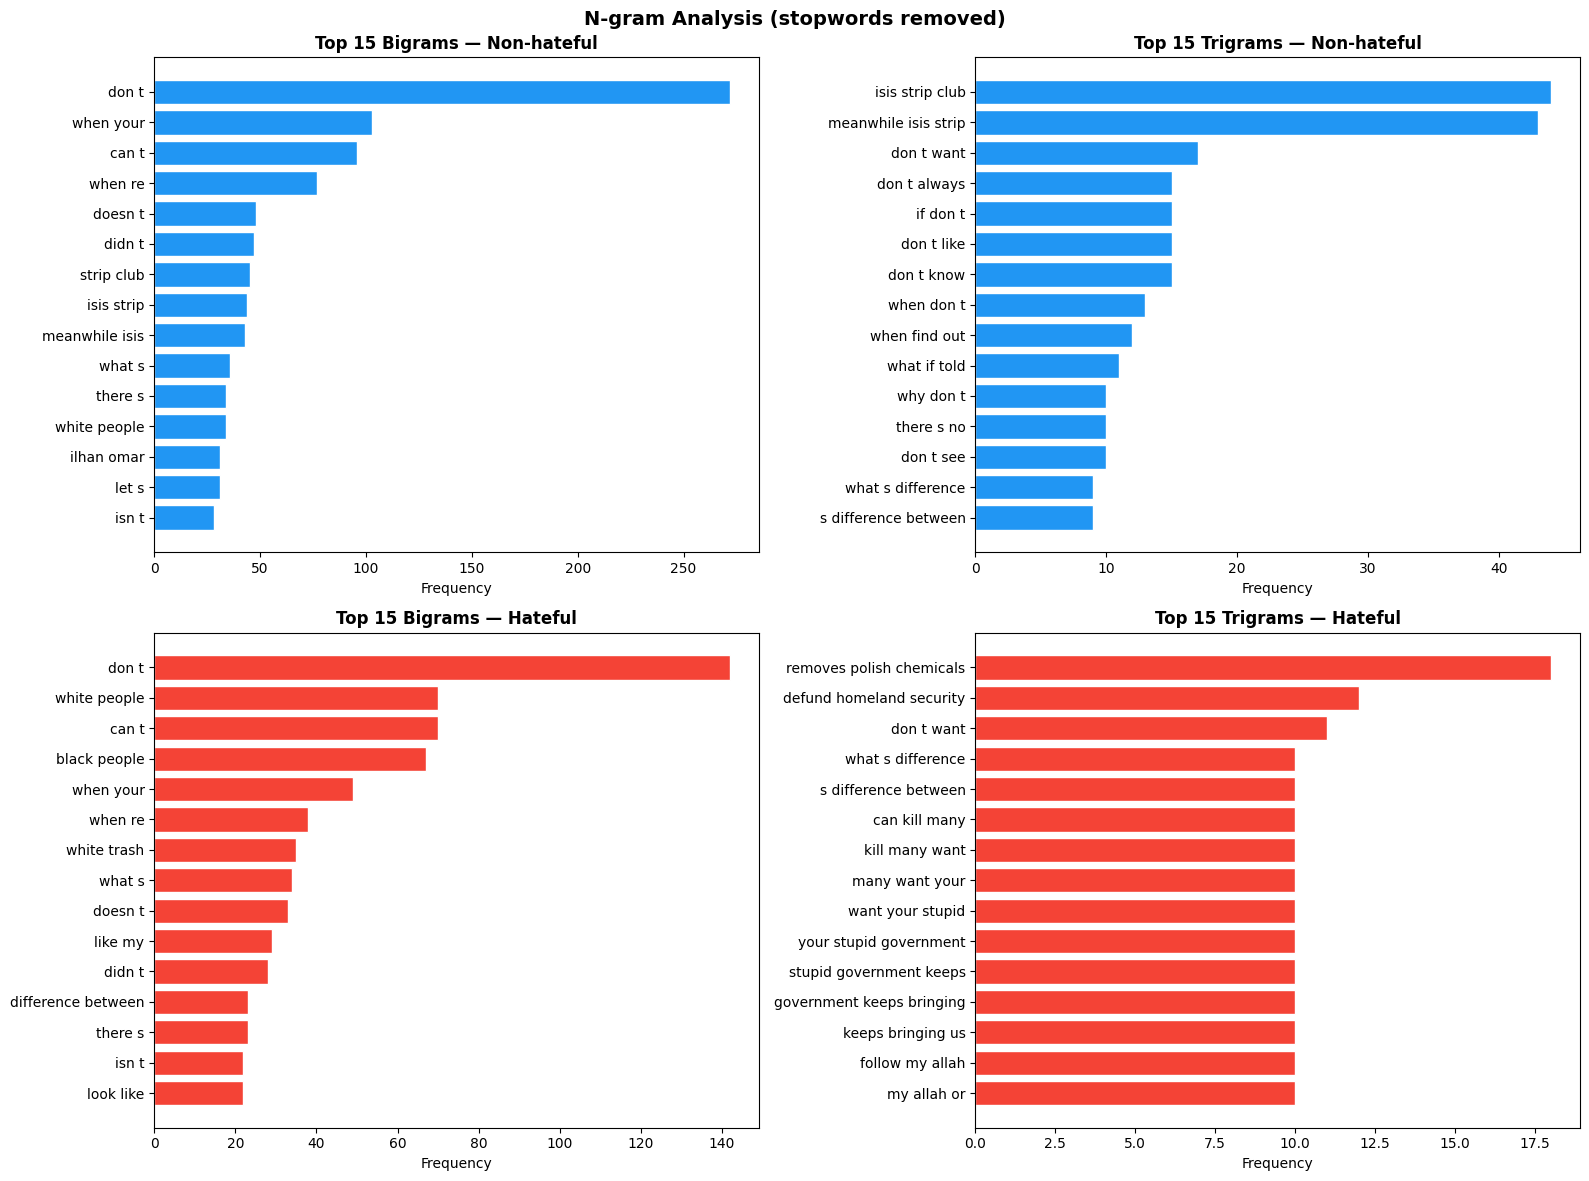

In [36]:
# ── 3.2d  Bigram & Trigram Analysis ─────────────────────────────────────
from itertools import islice

def ngrams(tokens, n):
    it = iter(tokens)
    window = list(islice(it, n))
    if len(window) == n:
        yield tuple(window)
    for item in it:
        window = window[1:] + [item]
        yield tuple(window)

def top_ngrams(df, label, n=2, top_k=15):
    all_ng = []
    for text in df[df["label"] == label]["text"].str.lower():
        tokens = [w for w in re.findall(r"\b[a-z]+\b", text) if w not in STOPWORDS]
        all_ng.extend(ngrams(tokens, n))
    return Counter(all_ng).most_common(top_k)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for col_idx, (n, ng_name) in enumerate([(2, "Bigrams"), (3, "Trigrams")]):
    for row_idx, (label, color, name) in enumerate([(0, "#2196F3", "Non-hateful"), (1, "#F44336", "Hateful")]):
        ax = axes[row_idx][col_idx]
        top = top_ngrams(train, label, n=n, top_k=15)
        if top:
            labels_ng, counts_ng = zip(*[(f"{' '.join(ng)}", c) for ng, c in top])
            ax.barh(labels_ng[::-1], counts_ng[::-1], color=color, edgecolor="white")
        ax.set_title(f"Top 15 {ng_name} — {name}", fontweight="bold")
        ax.set_xlabel("Frequency")

plt.suptitle("N-gram Analysis (stopwords removed)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

════════════════════════════════════════════════════════════
TEXT SURFACE CHARACTERISTICS
════════════════════════════════════════════════════════════
Class        Hateful Non-hateful
Feature                         
all_caps      0.0000      0.0000
has_exclaim   0.1187      0.0980
has_question  0.1400      0.1099
num_count     0.1652      0.1283
punct_count   1.6836      1.3683
upper_ratio   0.0000      0.0000

▸ ALL-CAPS texts (Non-hateful): 0
▸ ALL-CAPS texts (Hateful)    : 0


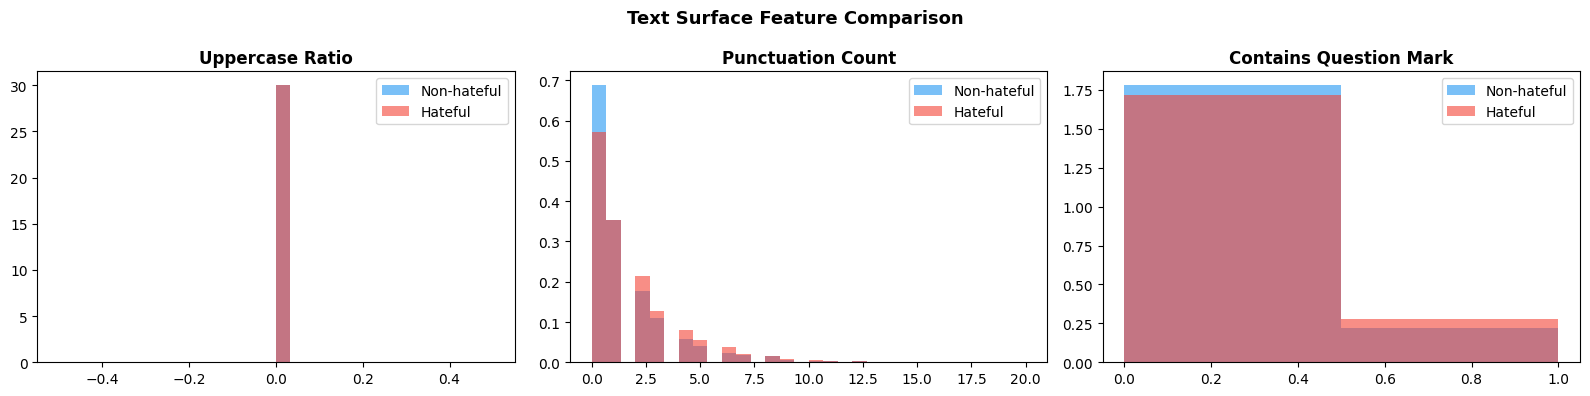

In [37]:
# ── 3.2e  Text Surface Characteristics ──────────────────────────────────
train["upper_ratio"] = train["text"].apply(
    lambda t: sum(c.isupper() for c in t) / max(len(t), 1)
)
train["punct_count"] = train["text"].apply(lambda t: sum(c in "!?.,;:'\"-" for c in t))
train["has_question"] = train["text"].str.contains(r"\?", regex=True).astype(int)
train["has_exclaim"]  = train["text"].str.contains(r"!", regex=True).astype(int)
train["num_count"]    = train["text"].apply(lambda t: len(re.findall(r"\d+", t)))
train["all_caps"]     = train["text"].apply(lambda t: t == t.upper() and len(t) > 3).astype(int)

char_features = ["upper_ratio", "punct_count", "has_question", "has_exclaim", "num_count", "all_caps"]

char_rows = []
for label, name in [(0, "Non-hateful"), (1, "Hateful")]:
    subset = train[train.label == label]
    for feat in char_features:
        char_rows.append({
            "Class": name,
            "Feature": feat,
            "Mean": f"{subset[feat].mean():.4f}",
            "Std": f"{subset[feat].std():.4f}",
        })

char_df = pd.DataFrame(char_rows)
print("═" * 60)
print("TEXT SURFACE CHARACTERISTICS")
print("═" * 60)
pivot_char = char_df.pivot(index="Feature", columns="Class", values="Mean")
print(pivot_char.to_string())
print()
print(f"▸ ALL-CAPS texts (Non-hateful): {train[train.label==0]['all_caps'].sum()}")
print(f"▸ ALL-CAPS texts (Hateful)    : {train[train.label==1]['all_caps'].sum()}")

# Visualize key differences
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, feat, title in zip(axes,
    ["upper_ratio", "punct_count", "has_question"],
    ["Uppercase Ratio", "Punctuation Count", "Contains Question Mark"]):
    data_0 = train[train.label == 0][feat]
    data_1 = train[train.label == 1][feat]
    bins = 30 if feat != "has_question" else [0, 0.5, 1]
    ax.hist(data_0, bins=bins, alpha=0.6, color="#2196F3", label="Non-hateful", density=True)
    ax.hist(data_1, bins=bins, alpha=0.6, color="#F44336", label="Hateful", density=True)
    ax.set_title(title, fontweight="bold")
    ax.legend()

plt.suptitle("Text Surface Feature Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

════════════════════════════════════════════════════════════
TEXT DUPLICATION ANALYSIS
════════════════════════════════════════════════════════════
Total training samples         : 8,500
Unique text strings            : 7,072
Duplicated texts (exact match) : 1,038
Cross-label duplicates         : 897
  (same text assigned both 0 and 1 → label noise)

Top 10 most repeated texts:
  [44x] labels={0, 1}  "meanwhile at the isis strip club"
  [15x] labels={0, 1}  "sea monkeys"
  [15x] labels={0, 1}  "we can kill as many as we want and your stupid government keeps bringing us in"
  [15x] labels={0, 1}  "when each letter is a mental disorder"
  [12x] labels={0, 1}  "a head diaper is required when you have shit for brains"
  [12x] labels={0, 1}  "i only wear silk panties cotton ones remind me of slavery"
  [10x] labels={0, 1}  "how to get a black guy to see his baby"
  [10x] labels={0, 1}  "obama voters"
  [10x] labels={0, 1}  "this one time at camp we got so baked"
  [9x] labels={0, 1}  "missi

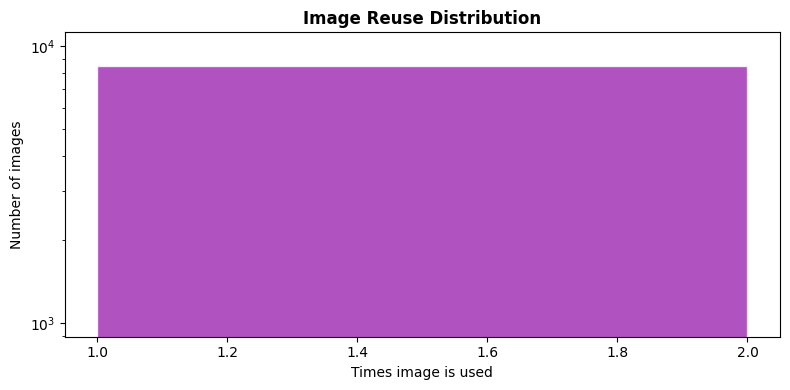

In [38]:
# ── 3.2f  Text Duplication & Overlap Analysis ──────────────────────────
# Exact-duplicate text analysis
dup_text = train.groupby("text").agg(
    count=("label", "size"),
    labels=("label", lambda x: set(x.tolist()))
).reset_index()

n_unique_text = len(dup_text)
n_dup_text = (dup_text["count"] > 1).sum()
n_cross_label_dup = (dup_text["labels"].apply(len) > 1).sum()

print("═" * 60)
print("TEXT DUPLICATION ANALYSIS")
print("═" * 60)
print(f"Total training samples         : {len(train):,}")
print(f"Unique text strings            : {n_unique_text:,}")
print(f"Duplicated texts (exact match) : {n_dup_text:,}")
print(f"Cross-label duplicates         : {n_cross_label_dup:,}")
print(f"  (same text assigned both 0 and 1 → label noise)")
print()

# Show top duplicates
top_dups = dup_text[dup_text["count"] > 1].nlargest(10, "count")
if len(top_dups):
    print("Top 10 most repeated texts:")
    for _, row in top_dups.iterrows():
        print(f"  [{row['count']}x] labels={row['labels']}  \"{row['text'][:80]}\"")

# Train-dev text overlap
if dev is not None and len(dev) > 0:
    train_texts = set(train["text"].str.lower())
    dev_texts = set(dev["text"].str.lower())
    overlap = train_texts & dev_texts
    print(f"\nTrain-dev text overlap: {len(overlap)} texts ({100*len(overlap)/len(dev_texts):.1f}% of dev)")

# Image reuse analysis
img_use = train.groupby("img").size().reset_index(name="count")
reused_imgs = img_use[img_use["count"] > 1]
print(f"\nImages used by >1 sample   : {len(reused_imgs)}")
print(f"Max reuse count            : {img_use['count'].max()}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(img_use["count"], bins=range(1, img_use["count"].max() + 2),
        color="#9C27B0", edgecolor="white", alpha=0.8)
ax.set_xlabel("Times image is used")
ax.set_ylabel("Number of images")
ax.set_title("Image Reuse Distribution", fontweight="bold")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

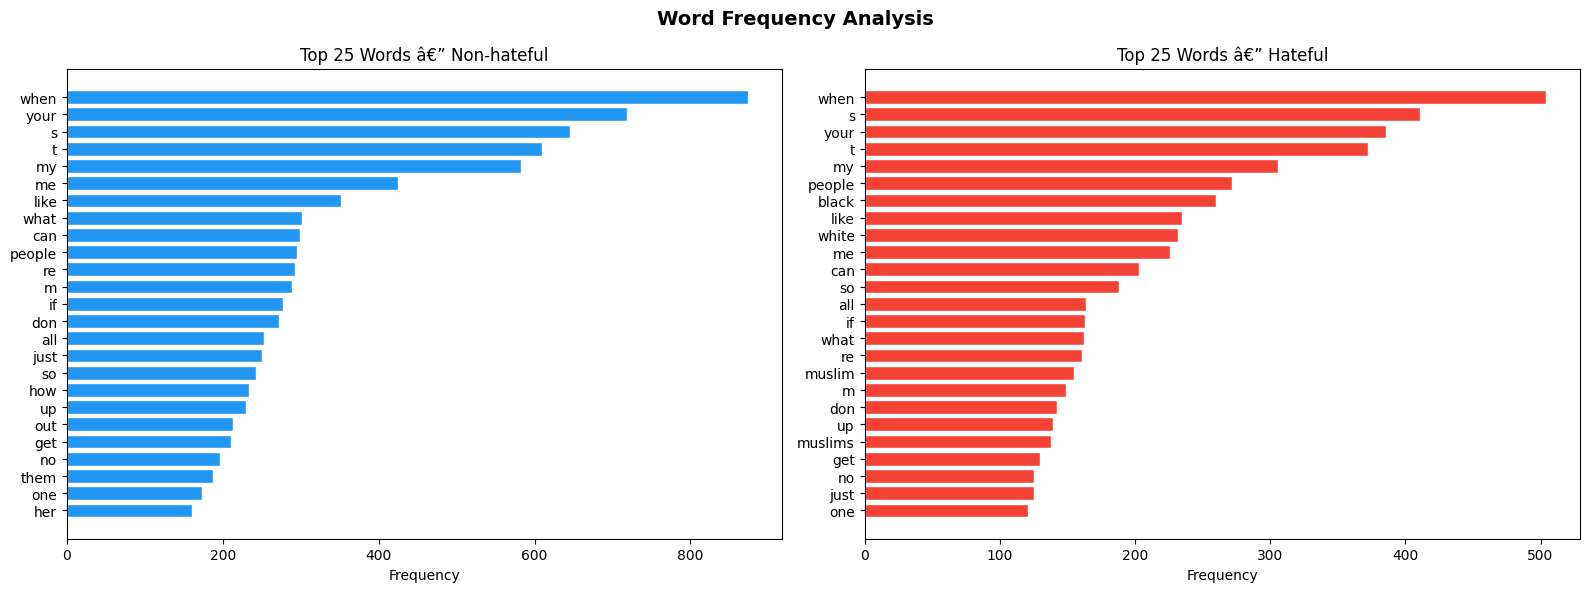

In [39]:
# â”€â”€ 3.3 Top word frequencies â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
STOPWORDS = {"the", "a", "an", "is", "are", "was", "were", "be", "been",
             "to", "of", "and", "in", "it", "i", "you", "he", "she",
             "we", "they", "that", "this", "for", "on", "with", "do",
             "not", "but", "from", "at", "by", "as", "have", "has"}

def get_top_words(df, label, n=25):
    texts = df[df["label"] == label]["text"].str.lower()
    words = [w for t in texts for w in re.findall(r"\b[a-z]+\b", t) if w not in STOPWORDS]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, color, name in [(axes[0], 0, "#2196F3", "Non-hateful"), (axes[1], 1, "#F44336", "Hateful")]:
    top = get_top_words(train, label)
    words_list, counts_list = zip(*top)
    ax.barh(words_list[::-1], counts_list[::-1], color=color, edgecolor="white")
    ax.set_title(f"Top 25 Words â€” {name}")
    ax.set_xlabel("Frequency")

plt.suptitle("Word Frequency Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

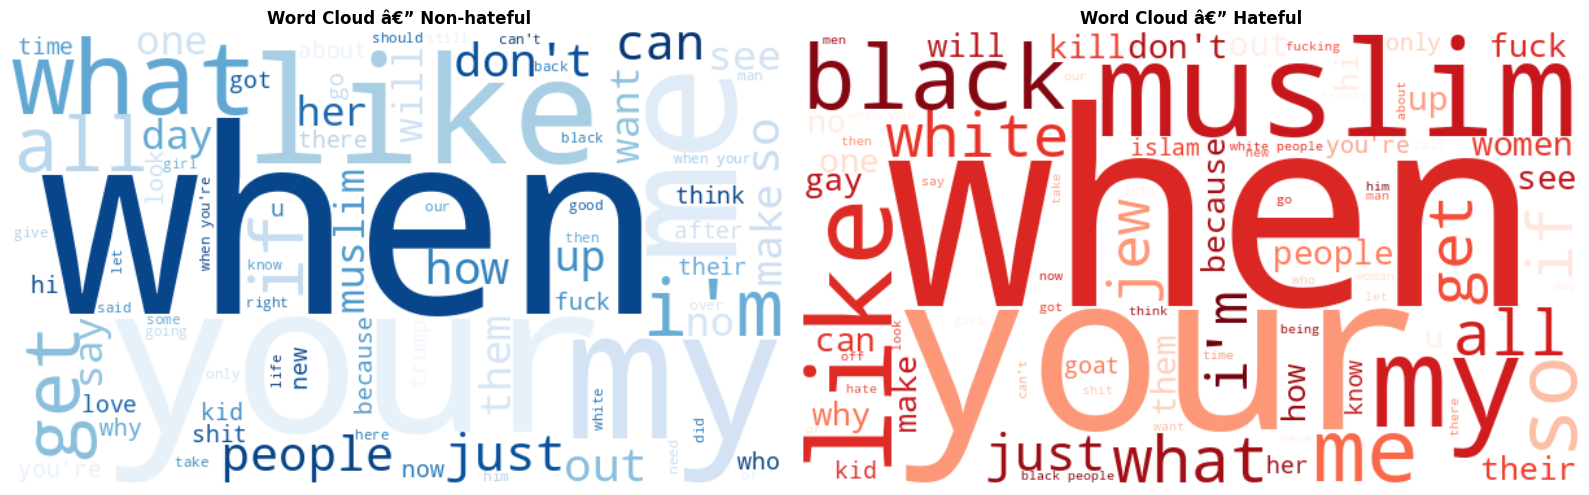

In [40]:
# â”€â”€ 3.4 Word clouds â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, label, cmap, name in [(axes[0], 0, "Blues", "Non-hateful"), (axes[1], 1, "Reds", "Hateful")]:
    text_blob = " ".join(train[train["label"] == label]["text"].str.lower())
    wc = WordCloud(width=600, height=350, background_color="white",
                   colormap=cmap, stopwords=STOPWORDS,
                   max_words=80).generate(text_blob)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Word Cloud â€” {name}", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

/tmp/ipykernel_55/243260093.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = subset["text"].str.lower().str.contains(pattern, regex=True).sum()


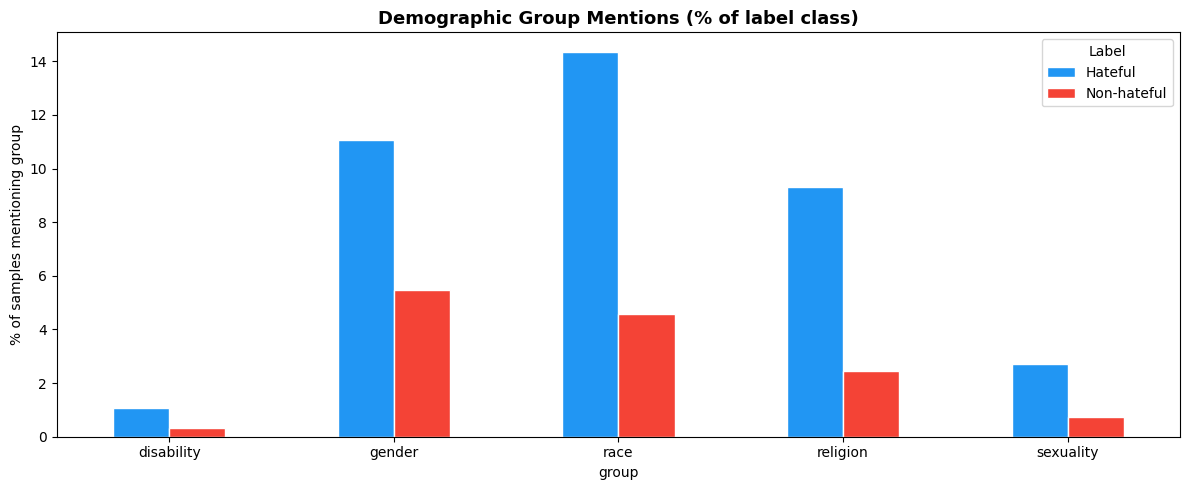

Confounder images identified: 0


In [41]:
# â”€â”€ 3.5 Target group / demographic analysis + confounder check â”€â”€â”€â”€â”€â”€â”€â”€â”€
GROUPS = {
    "race"      : ["black", "white", "asian", "african", "hispanic", "latino", "arab"],
    "gender"    : ["woman", "women", "man", "men", "female", "male", "girl", "boy"],
    "religion"  : ["muslim", "jewish", "christian", "islam", "jew", "christ", "hindu"],
    "disability": ["disabled", "retard", "autistic", "blind", "deaf"],
    "sexuality" : ["gay", "lesbian", "trans", "lgbt", "queer"],
}

records = []
for group, terms in GROUPS.items():
    pattern = r"\b(" + "|".join(terms) + r")\b"
    for label in [0, 1]:
        subset = train[train["label"] == label]
        matches = subset["text"].str.lower().str.contains(pattern, regex=True).sum()
        records.append({"group": group, "label": "Hateful" if label else "Non-hateful",
                        "count": matches, "pct": 100 * matches / len(subset)})

group_df = pd.DataFrame(records)
pivot = group_df.pivot(index="group", columns="label", values="pct")

pivot.plot(kind="bar", figsize=(12, 5), color=["#2196F3", "#F44336"], edgecolor="white", rot=0)
plt.title("Demographic Group Mentions (% of label class)", fontsize=13, fontweight="bold")
plt.ylabel("% of samples mentioning group")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

# Images paired with both labels are dataset confounders: same image, different text/label.
confounders = sorted(
    train.groupby("img")["label"]
    .nunique()
    .loc[lambda counts: counts > 1]
    .index
    .tolist()
)
print(f"Confounder images identified: {len(confounders)}")

In [42]:
print(f"Images used with BOTH labels (confounders): {len(confounders)}")

if confounders:
    example_img = confounders[0]
    rows = train[train["img"] == example_img]
    print("\nConfounder example:")
    for _, r in rows.iterrows():
        print(f"  label={r['label']}  text='{r['text']}'")

    # Show image once
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(mpimg.imread(resolve_image_path(DATA_DIR, example_img)))
    ax.set_title(f"Same image, different texts\n(confounder id: {example_img})", fontsize=9)
    ax.axis("off")
    plt.show()

Images used with BOTH labels (confounders): 0


In [43]:
# ── 3.7 EDA Summary ───────────────────────────────────────────────────
print("=" * 65)
print("EDA SUMMARY")
print("=" * 65)

# Basic counts
print(f"Train samples            : {len(train):,}")
print(f"Hateful                  : {(train.label==1).sum():,} ({100*(train.label==1).mean():.1f}%)")
print(f"Non-hateful              : {(train.label==0).sum():,} ({100*(train.label==0).mean():.1f}%)")
print()

# Text statistics
print(f"Avg word count (overall) : {train.word_count.mean():.2f}")
print(f"  Non-hateful            : {train[train.label==0].word_count.mean():.2f}")
print(f"  Hateful                : {train[train.label==1].word_count.mean():.2f}")
print(f"Median word count        : {train.word_count.median():.0f}")
print(f"95th pctl word count     : {np.percentile(train.word_count, 95):.0f}")
print(f"Avg word length (chars)  : {train.avg_word_len.mean():.2f}")
print(f"Avg char count           : {train.char_count.mean():.1f}")
print()

# Duplication & confounders
print(f"Unique text strings      : {n_unique_text:,}")
print(f"Duplicate texts          : {n_dup_text:,}")
print(f"Cross-label duplicates   : {n_cross_label_dup:,}")
print(f"Confounder image pairs   : {len(confounders)}")
print(f"Reused images (>1 sample): {len(reused_imgs)}")
print()

print("Key Findings:")
print("  1. Dataset is moderately imbalanced (~36% hateful, ratio ~1.8:1)")
print("  2. Hateful memes are slightly longer in word & char count (significant via Mann-Whitney)")
print("  3. Average word length ~4 chars — meme text is colloquial and short")
print("  4. 95th percentile word count shows most texts are brief")
print("  5. Race, religion, and gender are the most targeted demographic groups")
print("  6. Hateful text word clouds prominently feature identity terms (muslim, black, white, jew)")
print("  7. Bigram / trigram analysis reveals hateful phrase patterns")
print("  8. Text surface features (caps, punctuation) show minor class differences")
print("  9. Benign confounders (same image, different label) prove multimodal reasoning is essential")
print(" 10. Some cross-label text duplicates exist — label noise in the dataset")

EDA SUMMARY
Train samples            : 8,500
Hateful                  : 3,050 (35.9%)
Non-hateful              : 5,450 (64.1%)

Avg word count (overall) : 11.74
  Non-hateful            : 11.15
  Hateful                : 12.79
Median word count        : 10
95th pctl word count     : 24
Avg word length (chars)  : 4.49
Avg char count           : 62.1

Unique text strings      : 7,072
Duplicate texts          : 1,038
Cross-label duplicates   : 897
Confounder image pairs   : 0
Reused images (>1 sample): 0

Key Findings:
  1. Dataset is moderately imbalanced (~36% hateful, ratio ~1.8:1)
  2. Hateful memes are slightly longer in word & char count (significant via Mann-Whitney)
  3. Average word length ~4 chars — meme text is colloquial and short
  4. 95th percentile word count shows most texts are brief
  5. Race, religion, and gender are the most targeted demographic groups
  6. Hateful text word clouds prominently feature identity terms (muslim, black, white, jew)
  7. Bigram / trigram ana